# Makemore Part 3 — MLP Character-Level Language Model

Based on Andrej Karpathy's makemore series. Architecture from **Bengio et al. (2003)** — *"A Neural Probabilistic Language Model"*.

## The Big Idea
Given the last **3 characters**, predict the **next character**. Sample repeatedly → generate new names.

**Why move beyond bigram (Part 1-2)?**  
The bigram model only sees 1 prior character. An MLP with a context window of N characters captures more structure and long-range patterns in the language.

## Full Pipeline
1. Build vocabulary (char → integer mapping)
2. Construct training examples: `[3 chars] → next char`
3. Define MLP: embed → hidden (tanh) → output logits
4. Train with minibatch SGD + cross-entropy loss
5. Sample new names autoregressively

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

## Step 1 — Load Data

We use a dataset of Indian names. Each name becomes a sequence of characters the model learns to mimic.

- Dots `.` are stripped from names (we'll use `.` as our own special start/end-of-word token)
- Everything is lowercased so the vocabulary stays small (26 letters + 1 special = 27 total)

In [2]:
import os
import requests

USE_LOCAL = True
LOCAL_FILE = "Indian_names_kaggle.txt"
url = "https://raw.githubusercontent.com/abhishek-marathe04/makemore/refs/heads/main/Indian_names_kaggle.txt"

def load_words_from_text(text: str):
    return text.replace(".", "").lower().splitlines()

words = None

if USE_LOCAL:
    local_path = os.path.join(os.getcwd(), LOCAL_FILE)
    if os.path.exists(local_path):
        with open(local_path, "r", encoding="utf-8") as f:
            words = load_words_from_text(f.read())
        print(f"Loaded {len(words)} names from local file: {local_path}")
    else:
        print(f"Local file not found ({local_path}). Falling back to download...")

if words is None:
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    words = load_words_from_text(response.text)
    print(f"Downloaded {len(words)} names from URL.")

Local file not found (/content/Indian_names_kaggle.txt). Falling back to download...
Downloaded 55689 names from URL.


## Step 2 — Build Vocabulary (Tokenization)

We need to map every character to an integer so we can use it in PyTorch tensors. This is the simplest possible tokenizer — character-level, no subwords.

- **`stoi`** (string-to-int): `{'a': 1, 'b': 2, ..., '.': 0}` — assigns a unique integer to each character
- **`itos`** (int-to-string): reverse mapping, used when decoding predictions back to readable characters
- **`.` gets index 0** — it acts as both the start-of-word and end-of-word token. When we see `.` as output, we stop generating.
- **`vocab_size = 27`**: 26 letters + 1 special token

In [3]:
# Build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))  # All unique characters across all names
stoi = {s:i+1 for i, s in enumerate(chars)}  # char→int starting at 1 (reserve 0 for special token)
stoi['.'] = 0   # '.' is our start/end-of-word token, always mapped to 0
itos = {i:s for s, i in stoi.items()}  # int→char: flip stoi for decoding
vocab_size = len(itos)

print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


## Step 3 — Build the Dataset (Sliding Context Window)

For each word, we slide a window of size 3 across the characters and record `(context → next_char)` pairs. This is the core supervised learning setup.

**Example for the word "cat":**

| context | → | target |
|---------|---|--------|
| `[. . .]` | → | `c` |
| `[. . c]` | → | `a` |
| `[. c a]` | → | `t` |
| `[c a t]` | → | `.` (end of word) |

**Why split into train / val / test?**
- **Train (80%)**: what the model learns from
- **Val (10%)**: used to monitor overfitting *during development* — we tune hyperparameters based on this
- **Test (10%)**: held out completely, only used for a final honest evaluation at the end

Shuffling with `random.seed(42)` ensures reproducibility — same shuffle every run, but names appear in random order so the model doesn't learn any positional patterns.

In [4]:
import torch
import random

block_size = 3  # How many prior characters we use to predict the next one (context window size)

def build_dataset(words):
    print(len(words))
    X = []  # Inputs: each row is 3 character indices (the context)
    Y = []  # Targets: each value is the index of the next character to predict

    for w in words:
        context = [0] * block_size  # Start with all '.' tokens (index 0) — "beginning of word" padding
        for ch in w + '.':          # Iterate through each char in the word, plus the '.' end token
            ix = stoi[ch]
            X.append(context)       # Current context is the input
            Y.append(ix)            # Next character is the label
            context = context[1:] + [ix]  # Slide the window: drop oldest char, append the new one

    X = torch.tensor(X)  # Shape: (N, block_size) — N training examples, each with 3 context indices
    Y = torch.tensor(Y)  # Shape: (N,) — the target character index for each example
    return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))  # 80% train
n2 = int(0.9 * len(words))  # 90% = train + val, remaining 10% is test

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

44551
5569
5569


## Step 4 — Define the MLP

Architecture from Bengio et al. (2003):

```
Input: 3 char indices
  → C  (27×10 embedding table): each index → 10-dim dense vector
  → concatenate 3 embeddings → 30-dim vector
  → W1 (30×200) + b1 → 200 hidden units
  → tanh activation (adds non-linearity)
  → W2 (200×27) + b2 → 27 logits (one per vocabulary character)
  → softmax → probability distribution over next character
```

**Why embeddings instead of one-hot vectors?**  
One-hot vectors are sparse (27-dim with a single 1) and treat all characters as equally unrelated. Embeddings are **dense, learned representations** — the model can discover that 'a', 'e', 'i', 'o', 'u' are similar by placing them nearby in embedding space.

**Why tanh activation?**  
Without a non-linearity, stacking linear layers collapses to a single linear transformation — no matter how deep, it can't learn complex patterns. Tanh squashes values to `[-1, 1]` and enables the network to learn non-linear combinations.

**Parameter count breakdown:**
| Layer | Shape | Params |
|-------|-------|--------|
| C (embedding) | 27 × 10 | 270 |
| W1 | 30 × 200 | 6,000 |
| b1 | 200 | 200 |
| W2 | 200 × 27 | 5,400 |
| b2 | 27 | 27 |
| **Total** | | **~11,897** |

In [5]:
# MLP Revisited — manually define all parameters (no nn.Module, to understand what's happening inside)

n_embd = 10    # Dimension of character embedding vectors (each char → 10 numbers)
n_hidden = 200 # Number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647)  # Fixed seed for reproducibility

# Embedding table: one 10-dim vector for each character in the vocabulary
C  = torch.randn((vocab_size, n_embd),            generator=g, requires_grad=True)

# Hidden layer weights and bias
# Input to W1 is the concatenation of 3 embeddings: block_size * n_embd = 30
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g, requires_grad=True)
b1 = torch.randn(n_hidden,                        generator=g, requires_grad=True)

# Output layer: maps hidden state to a logit for each character in the vocab
W2 = torch.randn((n_hidden, vocab_size),          generator=g, requires_grad=True)
b2 = torch.randn(vocab_size,                      generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

print(f"Hidden Layers : {n_hidden}, embedding_dims : {n_embd}, input_values {vocab_size}, output_values: {vocab_size}")
print(f"Number of parameters in model: {sum(p.nelement() for p in parameters)}")

# requires_grad=True tells PyTorch to track gradients for these tensors during backprop
for p in parameters:
    p.requires_grad = True

Hidden Layers : 200, embedding_dims : 10, input_values 27, output_values: 27
Number of parameters in model: 11897


## Step 5 — Training Loop (Minibatch SGD)

We train by hand — no `optimizer.step()` — so every step is explicit and visible.

**Key ideas in this loop:**

- **Minibatching**: Instead of computing the loss over all ~44K examples at once (slow, memory-heavy), we randomly sample 32 examples per step. The gradient is noisy but fast, and the noise helps escape flat/bad regions.
- **Forward pass**: Run input through the network to get logits (raw scores), then compute loss.
- **`p.grad = None` before backward**: PyTorch *accumulates* gradients by default. If you don't zero them, gradients from different steps add up and corrupt the update. Setting to `None` is slightly more efficient than `.zero_()`.
- **`loss.backward()`**: Autograd walks backward through all operations, computing `dLoss/dParam` for every parameter.
- **Manual SGD update**: `param = param - lr * grad`. This is the most basic optimizer.
- **Learning rate decay**: Start at `lr=0.1` (big steps, fast learning), then drop to `lr=0.01` after step 10K (small steps, fine-tuning). This is a crude but effective schedule.

> **Note on the initial loss ~25**: A perfectly random model with 27 equally likely outputs should have a loss of `log(27) ≈ 3.3`. Starting at 25 means the model is wildly overconfident in wrong answers — a symptom of **bad weight initialization** (weights too large → extreme logits → saturated tanh). Fixing this is the main topic of Part 4 (BatchNorm / careful init).

In [6]:
max_steps = 20000
batch_size = 32
lossi = []  # Track loss at each step for plotting

for i in range(max_steps):

    # --- Mini-batch construction ---
    # Pick batch_size random indices from the training set
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]  # Shape: Xb=(32,3), Yb=(32,)

    # --- Forward pass ---
    emb = C[Xb]                        # Look up embeddings: (32, 3, 10) — each of the 3 context chars gets a 10-dim vector
    embcat = emb.view(emb.shape[0], -1) # Flatten/concatenate embeddings: (32, 30) — treat all 3 char embeddings as one vector
    hpreact = embcat @ W1 + b1          # Linear transform to hidden layer: (32, 200)
    h = torch.tanh(hpreact)             # Apply tanh non-linearity: (32, 200) — squashes to [-1, 1]
    logits = h @ W2 + b2                # Project to output vocab size: (32, 27) — raw scores, not probabilities yet
    loss = F.cross_entropy(logits, Yb)  # Cross-entropy = softmax + negative log likelihood in one stable op

    # --- Backward pass ---
    for p in parameters:
        p.grad = None       # Zero gradients before computing new ones (avoid accumulation across steps)
    loss.backward()         # Compute gradients via autograd (chain rule through entire forward pass)

    # --- Parameter update (manual SGD) ---
    lr = 0.1 if i < 10000 else 0.01  # Learning rate schedule: fast early, slow later for fine-tuning
    for p in parameters:
        p.data += -lr * p.grad        # Gradient descent: move each param in the direction that reduces loss

    # --- Logging ---
    if i % 1000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():4f}')
    lossi.append(loss.log10().item())  # Store log10(loss) — compresses range and makes trend easier to plot

      0/  20000: 25.311033
   1000/  20000: 3.341165
   2000/  20000: 2.628375
   3000/  20000: 2.950238
   4000/  20000: 2.454400
   5000/  20000: 2.132030
   6000/  20000: 3.087233
   7000/  20000: 2.087971
   8000/  20000: 2.728902
   9000/  20000: 2.166472
  10000/  20000: 1.960818
  11000/  20000: 2.242973
  12000/  20000: 1.896784
  13000/  20000: 2.193956
  14000/  20000: 2.219597
  15000/  20000: 1.936736
  16000/  20000: 2.100238
  17000/  20000: 1.917480
  18000/  20000: 1.905317
  19000/  20000: 2.408136


## Loss Curve

Plot the training loss over time to visually diagnose training.

**What to look for:**
- **Downward trend** — model is learning
- **Spikes or instability** — learning rate too high
- **Flat plateau early** — learning rate too low, or model stuck
- **Sudden drop at step 10K** — the learning rate decay kicking in

We plot `log10(loss)` rather than raw loss. Because minibatch losses are noisy, the log scale compresses spikes and makes the overall trend clearer.

## Activation & Gradient Analysis — Diagnosing the Network Internals

After training, we inspect the **internal state** of the network to diagnose whether gradients are flowing properly during backprop.

### The Core Question: Are Our Tanh Neurons Saturated?

The `tanh` function maps any real number to the range (-1, +1):

```
tanh(x) ≈ x          when x is near 0     → derivative ≈ 1 → gradient flows freely  ✅
tanh(x) ≈ ±1         when x is very large → derivative ≈ 0 → gradient vanishes       ❌
```

When a neuron's pre-activation value (`hpreact`) is very large in magnitude, `tanh` squashes it to ±1. The gradient of `tanh` at ±1 is essentially **zero**, which means:
- That neuron contributes ~zero gradient during backprop
- Its incoming weights receive ~zero update
- If many neurons saturate → **vanishing gradient problem** → training stalls

### What We'll Check

1. **`h` (post-tanh output)**: Should be distributed across (-1, +1), not piled up at the extremes ±1
2. **`hpreact` (pre-activation, input to tanh)**: Should be a narrow Gaussian centered at 0
3. **Saturation heatmap**: Visualize which specific neurons are "dead" (stuck at ±1 for every input)

(array([2050.,  263.,  143.,   74.,   39.,   33.,   53.,   42.,   38.,
          29.,   22.,   19.,   12.,   20.,   15.,   16.,   19.,   20.,
          18.,   13.,   20.,   11.,   19.,    9.,   16.,   18.,   15.,
          13.,   15.,    7.,   18.,   17.,    9.,   11.,   14.,   17.,
          18.,   16.,   27.,   23.,   40.,   30.,   29.,   37.,   59.,
          88.,  101.,  158.,  263., 2344.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

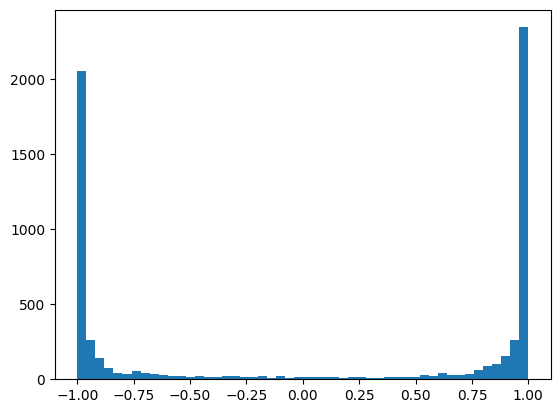

In [7]:
# We can see, Most of the values are either -1 or 1, and all these values that are 1 or -1 are in flat
# region of tanh, And what will happen is, gradients will be vanished ( check tanh formula for gradient)

plt.hist(h.view(-1).tolist(), 50)

### Pre-Activation Distribution (`hpreact = embcat @ W1 + b1`)

Now let's look at what the values look like **before** tanh is applied.

**Mean (μ)**: The average value of the distribution — where is it centered?
- Ideal: mean ≈ 0, so tanh operates symmetrically

**Standard Deviation (σ)**: Measures how spread out the values are around the mean.
- σ = 1 → 68% of values fall within ±1 → tanh is in its linear zone → gradients ≈ 1
- σ = 5 → values spread far from 0 → tanh saturated at ±1 → gradients ≈ 0

**Why does `hpreact` end up so broad with default init?**

`hpreact = embcat @ W1 + b1`, where `embcat` is shape `(batch, 30)` and `W1 ~ N(0,1)`.

The variance of a dot product sums up contributions from each of the 30 inputs:
```
Var(hpreact) ≈ fan_in × Var(W1) = 30 × 1 = 30   →   std ≈ √30 ≈ 5.5
```

So standard random initialization makes pre-activations ~5.5x too large, pushing tanh deep into its flat, zero-gradient region on both sides.

(array([  1.,   0.,   0.,   3.,   2.,   1.,   4.,   4.,  12.,  20.,  18.,
         42.,  38.,  59.,  94., 120., 141., 215., 232., 340., 316., 489.,
        418., 288., 265., 286., 532., 514., 372., 346., 270., 217., 220.,
        120., 123.,  79.,  72.,  27.,  32.,  24.,   7.,  10.,  16.,   5.,
          2.,   0.,   0.,   0.,   2.,   2.]),
 array([-17.5246067 , -16.81082233, -16.09703796, -15.38325359,
        -14.66946922, -13.95568485, -13.24190048, -12.52811611,
        -11.81433174, -11.10054737, -10.386763  ,  -9.67297863,
         -8.95919426,  -8.24540989,  -7.53162552,  -6.81784115,
         -6.10405678,  -5.39027241,  -4.67648804,  -3.96270367,
         -3.2489193 ,  -2.53513493,  -1.82135056,  -1.10756618,
         -0.39378181,   0.32000256,   1.03378693,   1.7475713 ,
          2.46135567,   3.17514004,   3.88892441,   4.60270878,
          5.31649315,   6.03027752,   6.74406189,   7.45784626,
          8.17163063,   8.885415  ,   9.59919937,  10.31298374,
         11.026768

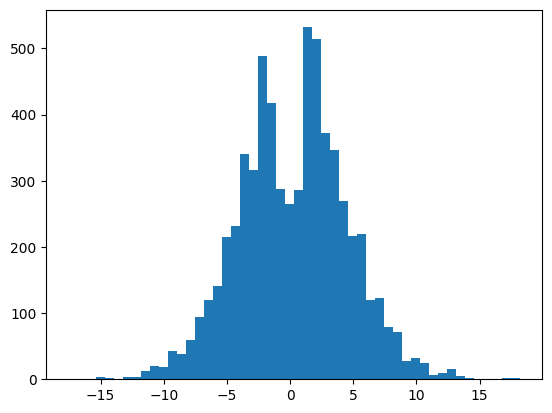

In [8]:
# Lets check pre activation, as we can see, its taking really brod values
plt.hist(hpreact.view(-1).tolist(), 50)

### Saturated Neuron Heatmap — Visualizing Dead Neurons

This heatmap shows which neurons are "stuck" in the flat saturated region of tanh (`|h| > 0.99`).

**Reading the heatmap:**
- **Rows** = individual training examples in the last batch
- **Columns** = the 200 hidden neurons
- **White cell** = `|h[example, neuron]| > 0.99` → tanh output is ±1 → gradient ≈ 0 → this neuron contributes nothing to learning for this example
- **Black cell** = neuron is in the healthy linear zone → gradient flows → the neuron is learning

**What to look for:**
- **Scattered white** = some saturation is OK, neurons still receive gradient from most examples
- **Fully white column** = a **dead neuron** — saturated for EVERY example in the batch
  - Dead neurons receive near-zero gradient from every single training example
  - Their weights never update → permanently wasted model capacity
  - Can only be "revived" by a lucky weight update from another path (rarely happens)
- **Mostly white** = near-total gradient collapse, the model is barely learning

**The fix**: Better weight initialization (Kaiming init, shown next) shrinks pre-activations so tanh stays in the black zone.

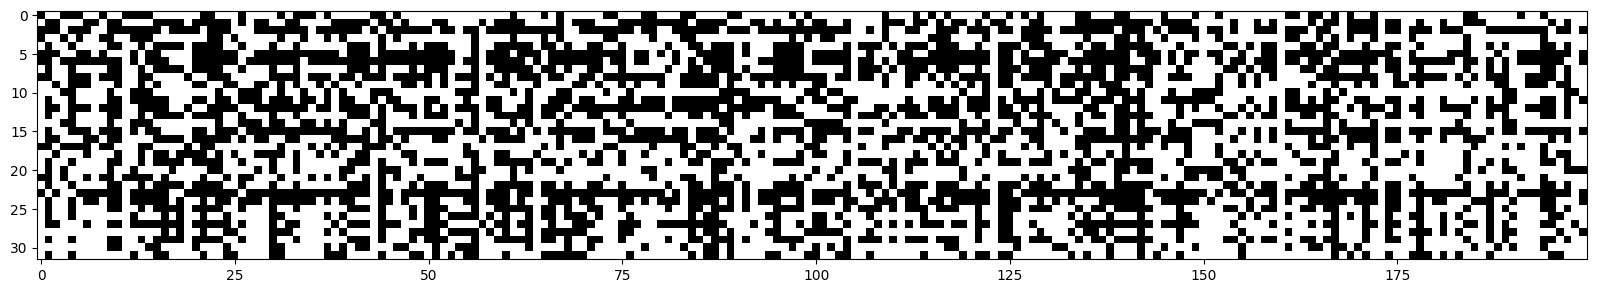

In [9]:
# Following figure shows, all these white spaces indicate, tanh layer is really active in that neuron
# If lets say whole column is white, then its a dead nueron, in that case, no single example ever activates tanh
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest') # This is boolean tensor, you get white if true, or black

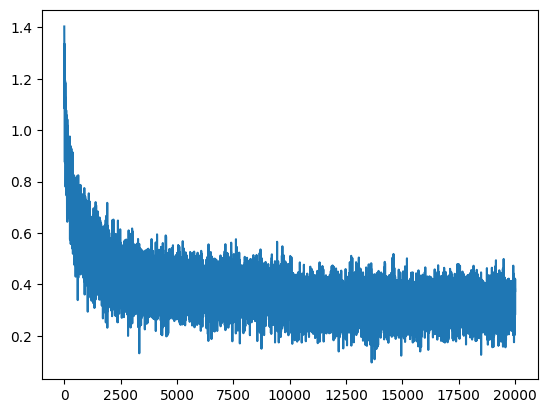

In [10]:
plt.plot(lossi)

## Step 6 — Evaluate on Train / Val / Test

We measure the loss on each data split to check for **overfitting**.

| Scenario | What it means |
|----------|---------------|
| train ≈ val | Healthy — model generalizes well |
| train << val | Overfitting — memorized training data, doesn't generalize |
| train ≈ val, both high | Underfitting — model needs more capacity or longer training |

`@torch.no_grad()` is a decorator that disables gradient tracking for everything inside the function. During evaluation we don't call `.backward()`, so there's no need to build the computation graph — this saves memory and runs faster.

## Proper Weight Initialization — Kaiming / He Init

### The Problem with Default Init

With `W1 = torch.randn(30, 200)` (std=1), the hidden layer pre-activations blow up:
```
std(hpreact) ≈ √fan_in = √30 ≈ 5.5   →   tanh saturates   →   gradients vanish
```

We need to scale down `W1` so the **signal variance is preserved** as it passes through the layer.

### Mean and Standard Deviation — What They Mean

**Mean (μ)**: The expected (average) value.
```
μ = (1/N) Σ xᵢ
```
- For weights: we want μ = 0 — no systematic push in any direction
- For activations: μ ≈ 0 means the network isn't systematically biased

**Standard Deviation (σ)**: How spread out the values are around the mean.
```
σ = √( (1/N) Σ (xᵢ - μ)² )
```
- σ = 1 means 68% of values are within ±1 of the mean (the "normal" range for tanh)
- For activations into tanh: σ ≈ 1 is ideal — most inputs land in the linear region

### Kaiming (He) Initialization

From *"Delving Deep into Rectifiers"* (He et al., 2015). The formula:

```
W ~ N(0, 1) × (gain / √fan_in)
```

- **`fan_in`** = number of input connections to the layer (here: `block_size × n_embd = 30`)
- **`gain`** = a correction factor for the non-linearity:
  - `tanh` → gain = `5/3` ≈ 1.67  (tanh compresses variance slightly, so we boost slightly)
  - `ReLU` → gain = `√2` ≈ 1.41
  - No activation → gain = 1.0

**Why `1/√fan_in`?**
When you compute a dot product of `fan_in` independent variables each with variance 1, the result has variance `fan_in`. Dividing by `√fan_in` brings it back to variance 1. The gain then fine-tunes for the specific activation function used.

**Result**: After Kaiming init, `std(hpreact) ≈ 1`, tanh stays in its linear zone, and gradients flow cleanly through every layer.

tensor(0.0092) tensor(1.0005)
tensor(-0.0028) tensor(1.0209)


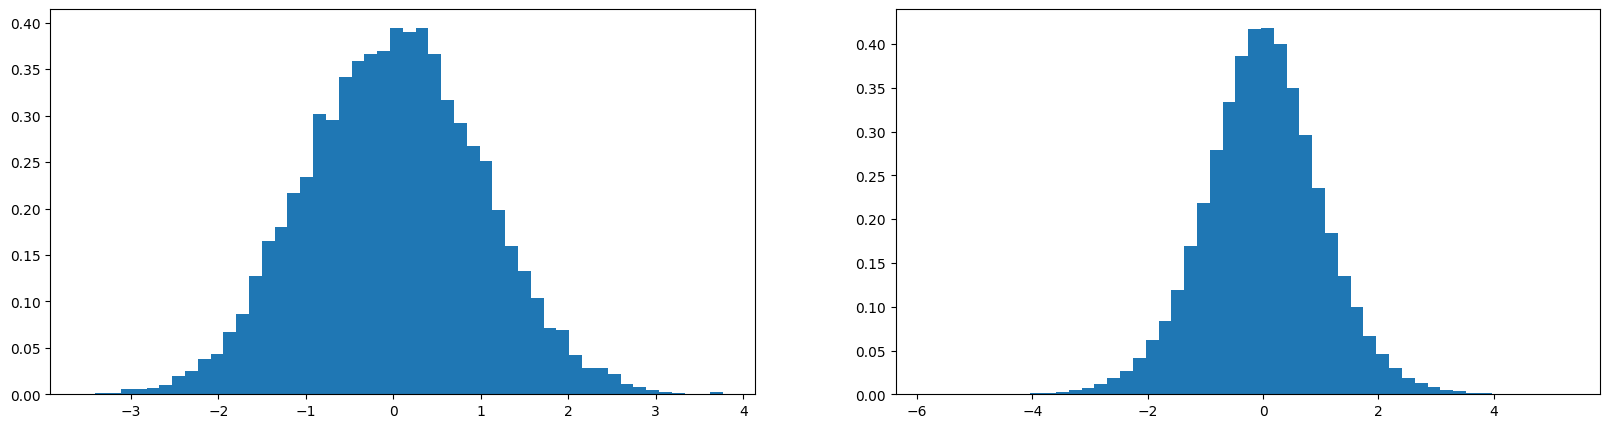

In [11]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) * 0.1 # As we can see, if we dont scale 2, y is taking huge values, so we need to reduce it, but question is by how much
# Mathematically, its sqaure root of fan_in ( which is input, in this case 10) 
# There is paper on this one, where they mentioned term kiamining init,
# So what happens is, as tanh is quashing function, we want some gain to make to more gaussian and equally distributed,
# That number is called as kiaming gain, it depends on actiation function you are using, for tanh, its (5/3) / square root of fan_in
w = torch.randn(10, 200) / 10 ** 0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50,  density=True);

## Fixing the Initial Loss — Output Layer Initialization

### The Problem at Step 0

At initialization, the model has learned nothing. The ideal "zero knowledge" state is:
> "Every next character is equally likely" → probability = 1/27 for each

**Expected initial loss** = `-log(1/27) = log(27) ≈ 3.296`

But with `W2 ~ N(0,1)` (random output weights), the logits vary wildly across the 27 outputs → `softmax` becomes extremely confident in some characters and near-zero for others. The model is **confidently wrong** → initial loss ≈ **25**.

This is harmful:
1. The model wastes thousands of training steps just unlearning its random overconfidence
2. Large logits → extreme softmax gradients → unstable, noisy early training
3. The loss curve shows a steep initial drop that's *not* actual learning — it's just recovering from bad init

### The Fix: Scale Down Output Weights
```python
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01  # was * 1 (default)
b2 = torch.zeros(vocab_size)                                   # was random
```

With all logits ≈ 0: `softmax([0, 0, ..., 0]) = [1/27, 1/27, ..., 1/27]` → loss ≈ log(27) ≈ 3.3.

The model starts from true uncertainty and every gradient step adds genuine information.

In [12]:
# Fixing the initial loss.
# In first iteration, our model has around loss of 25, 
# So 25% of time, our model is wrong, but that should not be the case, our model should be initilised such that, there should equal probablity model should give to each 27 characters
# That is
-torch.tensor(1/27).log()
# So initial log should be around 3, we are having very huge initilial loss as model is randomly assinging weights, and giving some numbers high weight which makes it more confident of them.

tensor(3.2958)

In [13]:
# 4 dimensional example of the issue
# logits = torch.tensor([15.0, 10.0, 5.0, 12.0])
logits = torch.randn(4) * 0.01
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, loss

(tensor([ 0.0061,  0.0012,  0.0013, -0.0105]), tensor(1.3845))

## Batch Normalization (BatchNorm)

*Ioffe & Szegedy, 2015 — "Batch Normalization: Accelerating Deep Network Training"*

### The Core Idea

Instead of carefully hand-tuning weight initialization to get the right activation scale, **BatchNorm automatically normalizes the pre-activations** inside the network at every forward pass. It makes the network robust to weight initialization.

The formula applied to `hpreact` (before tanh):

```
1. Compute batch mean:   μ  = mean(hpreact, dim=batch)      # mean across examples, per neuron
2. Compute batch std:    σ  = std(hpreact, dim=batch)        # std across examples, per neuron
3. Normalize:            hpreact_norm = (hpreact - μ) / (σ + ε)   # zero mean, unit std
4. Scale & shift:        hpreact_bn   = gamma * hpreact_norm + beta
```

- `ε` (epsilon, ~1e-5): a tiny constant added to σ to prevent division-by-zero
- **`gamma` (scale)**: learnable parameter, initialized to 1 — lets the network undo normalization if needed
- **`beta` (bias/shift)**: learnable parameter, initialized to 0 — lets the network shift the mean

After normalization, `hpreact_bn` has mean=0 and std=1 **per neuron across the batch** — right in the sweet spot for tanh.

---

### Mean and Std in BatchNorm — Detailed Definitions

**Batch Mean** (computed per neuron, across examples in the batch):
```
μⱼ = (1/m) Σᵢ hpreact[i, j]     for each neuron j, averaged over m examples
```
Answers: "What is the average activation of neuron j across this minibatch?"

**Batch Variance** (per neuron):
```
σⱼ² = (1/m) Σᵢ (hpreact[i,j] - μⱼ)²
```

**Batch Std**:
```
σⱼ = √(σⱼ² + ε)
```
After normalization, neuron j has mean=0 and std=1 across the batch — guaranteed, regardless of what W1 looks like.

---

### Running Mean and Running Std (for Inference)

**The problem at inference time**: We evaluate one example at a time. There's no "batch" to compute statistics over.

**The solution**: Track an **Exponential Moving Average (EMA)** of batch statistics *during training*:

```python
# During each training step (inside the training loop, no_grad):
bn_mean_running = 0.999 * bn_mean_running + 0.001 * bnmeani   # EMA of batch mean
bn_std_running  = 0.999 * bn_std_running  + 0.001 * bnstdi    # EMA of batch std
```

- **`0.999`** = momentum — how much of the old estimate to keep (99.9%)
- **`0.001`** = how much weight to give the new batch's statistics (0.1%)
- After many training steps, `bn_mean_running` converges to the true **population mean** (mean over the entire dataset, not just one batch)
- Same for `bn_std_running` → true **population std**

**At inference**: use the running statistics instead of batch statistics:
```python
hpreact_bn = gamma * (hpreact - bn_mean_running) / bn_std_running + beta
```

This ensures a single example is normalized the same way it would have been during training.

**Why not just always use batch stats?**
- Batch stats are noisy (different each minibatch) → fine for training (acts as regularization)
- At inference, we want **deterministic**, consistent normalization → use the stable running stats

---

### Why BatchNorm Works So Well

| Benefit | Explanation |
|---------|-------------|
| **Solves init sensitivity** | Even with bad W init, activations are re-centered before tanh |
| **Prevents saturation** | Forces std≈1 → tanh stays in linear zone → gradients flow |
| **Allows higher learning rates** | Stable activations → stable gradients → can step faster |
| **Slight regularization** | Batch stats are noisy → model can't perfectly memorize; acts like dropout |

**One subtle downside**: Batch statistics couple all examples in the minibatch together. The loss for one example now depends on which other examples happen to be in the same batch. This coupling can cause subtle bugs if you forget to switch to running stats at inference.

In [14]:
# =====================================================================
# Fifth Iteration: MLP with BatchNorm
# =====================================================================
# We add BatchNorm between the linear layer and tanh activation.
# New parameters: bngain (gamma) and bnbias (beta) — both learnable.
# New buffers:    bn_mean_running and bn_std_running — NOT parameters,
#                 updated manually during training, used at inference.
# =====================================================================

g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((vocab_size, n_embd),            generator=g)
# Kaiming init for W1: scale by gain/√fan_in. gain=5/3 for tanh.
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size)**0.5)
# No b1 here! BatchNorm has its own bias (bnbias), so b1 is redundant.

# Output layer: small weights → initial logits ≈ 0 → initial loss ≈ log(27) ≈ 3.3
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.zeros(vocab_size)

# --- BatchNorm parameters (learnable, updated by gradient descent) ---
bngain = torch.ones((1, n_hidden))   # gamma: scale factor, initialized to 1 (identity)
bnbias = torch.zeros((1, n_hidden))  # beta: shift factor, initialized to 0 (identity)

# --- BatchNorm running statistics (NOT parameters — updated manually with EMA) ---
# These are used at inference time when we don't have a batch to compute stats from.
bn_mean_running = torch.zeros((1, n_hidden))  # Starts at 0, converges to population mean
bn_std_running  = torch.ones((1, n_hidden))   # Starts at 1, converges to population std

parameters = [C, W1, W2, b2, bngain, bnbias]
print(f"Total parameters: {sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad = True

# -----------------------------------------------------------------------
# Training loop with BatchNorm
# -----------------------------------------------------------------------
max_steps = 20000
batch_size = 32
lossi_bn = []

for i in range(max_steps):
    # Minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # --- Forward pass ---
    emb = C[Xb]                                  # (batch, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)          # (batch, block_size*n_embd)
    hpreact = embcat @ W1                        # (batch, n_hidden) — no b1, BatchNorm handles bias

    # --- BatchNorm ---
    # Compute batch statistics (per neuron, across examples in the batch)
    bnmeani = hpreact.mean(0, keepdim=True)      # shape (1, n_hidden): mean across the batch
    bnstdi  = hpreact.std(0, keepdim=True)       # shape (1, n_hidden): std across the batch

    # Normalize: each neuron now has mean=0, std=1 across the batch
    hpreact = bngain * (hpreact - bnmeani) / (bnstdi + 1e-5) + bnbias

    # Update running stats (EMA) — torch.no_grad() because this is not part of the computation graph
    with torch.no_grad():
        # 0.999 * old_estimate + 0.001 * new_batch_statistic
        # After many steps: running stats ≈ true population mean/std
        bn_mean_running = 0.999 * bn_mean_running + 0.001 * bnmeani
        bn_std_running  = 0.999 * bn_std_running  + 0.001 * bnstdi

    h = torch.tanh(hpreact)                      # (batch, n_hidden) — now healthy, not saturated
    logits = h @ W2 + b2                         # (batch, vocab_size)
    loss = F.cross_entropy(logits, Yb)

    # --- Backward ---
    for p in parameters:
        p.grad = None
    loss.backward()

    # --- SGD update ---
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 2000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi_bn.append(loss.log10().item())

# -----------------------------------------------------------------------
# Evaluate with running statistics (inference mode)
# -----------------------------------------------------------------------
@torch.no_grad()
def split_loss_bn(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev), 'test': (Xte, Yte)}[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1
    # Use RUNNING stats at inference — not batch stats — for deterministic evaluation
    hpreact = bngain * (hpreact - bn_mean_running) / (bn_std_running + 1e-5) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")

split_loss_bn('train')
split_loss_bn('val')

Total parameters: 12097
      0/  20000: 3.2950
   2000/  20000: 1.7262
   4000/  20000: 1.9580
   6000/  20000: 2.1362
   8000/  20000: 1.7799
  10000/  20000: 1.8703
  12000/  20000: 1.9504
  14000/  20000: 1.7050
  16000/  20000: 1.9576
  18000/  20000: 1.7633
train loss: 1.9884
val loss: 1.9918


In [15]:
@torch.no_grad()  # Disable gradient tracking — we only need the forward pass here, saves memory
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]

    # Identical forward pass as training, but no loss.backward() will be called
    emb = C[x]                          # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1)    # (N, n_hidden)
    logits = h @ W2 + b2                # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")


split_loss('train')
split_loss('val')
# train ≈ val means no overfitting — the model generalizes to names it hasn't seen

train loss: 3.0713
val loss: 3.0808


## Step 7 — Sample New Names (Autoregressive Generation)

We generate one character at a time by repeatedly feeding the model its own predictions.

**Autoregressive sampling loop:**
1. Start with context `[., ., .]` — three start tokens
2. Run forward pass → get logits → softmax → probability distribution over 27 chars
3. **Sample** one character index from that distribution (`torch.multinomial`)
4. Append to the output, slide the context window forward
5. Stop when the model outputs `.` (the end-of-word token)

**Why `torch.multinomial` instead of `argmax`?**  
`argmax` always picks the single most probable character → output is deterministic and repetitive.  
`multinomial` samples *proportionally* to the probabilities → we get diverse outputs. Rare-but-possible characters still get sampled occasionally, which produces more varied and creative names.

## Training Iterations — Progressive Improvements

Each iteration fixes one specific initialization / architecture problem:

### Iteration 1 — Baseline (no fixes)
- train loss: 2.0915
- val loss:   2.0989
- **Problem**: Initial loss ~25 (model confidently wrong), tanh saturated, bad gradients

### Iteration 2 — Fix output layer (`W2 * 0.01`, `b2 = 0`)
- train loss: 1.9806
- val loss:   1.9940
- **Fix**: Initial logits ≈ 0 → softmax gives uniform 1/27 → initial loss ≈ log(27) ≈ 3.3

### Iteration 3 — Fix tanh saturation at init (`W1` scaled down)
- train loss: 1.9678
- val loss:   1.9734
- **Fix**: Scale `W1` down → `hpreact` std ≈ 1 → tanh not saturated → gradients flow

### Iteration 4 — Kaiming init (`W1 * (5/3) / √fan_in`)
- train loss: 1.9607
- val loss:   1.9676
- **Fix**: Principled scaling using gain=5/3 for tanh + 1/√fan_in variance preservation

### Iteration 5 — BatchNorm (see code cell below)
- **Fix**: Normalize pre-activations to mean=0, std=1 per neuron per batch
- Works automatically regardless of weight initialization
- Adds learnable `gamma`/`beta` so the network can choose the right scale
- Tracks `bn_mean_running` and `bn_std_running` (EMA) for use at inference time

In [18]:
# Sample from the trained model — generate 20 new names
g = torch.Generator().manual_seed(2147483647 + 102)  # Fixed seed → same names every run

for _ in range(20):
    out = []
    context = [0] * block_size  # Start with [., ., .] — the "nothing has been said yet" state

    while True:
        # Forward pass with just this one context window
        emb = C[torch.tensor([context])]    # (1, block_size, n_embd) — embed the 3 context chars
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)  # (1, n_hidden)
        logits = h @ W2 + b2                # (1, 27) — raw scores for each possible next char
        probs = F.softmax(logits, dim=1)    # Convert logits to probabilities (sum to 1)

        # Sample one character index according to the probability distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # Slide the context window: drop the oldest char, add the newly sampled one
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:  # If we sampled '.', that's the end-of-word signal — stop
            break

    print(''.join(itos[i] for i in out))  # Decode to string, strip the trailing '.'

driprrindihrvatrirshinijekritrgosridtregpridhrondbisrimurlmxhrrshrshulejlsthirispatqbarrikilkillthrrjsweprishanejlizdhtkagmdsidrishishrorpojlopprnim.
dojposrindosbrkrisrishrvipwrismjvistisrjaswrthrlmosrishiveddhbglidhamshillridrijetsubmizrivgosvishsvamwalnyuryrinliniprabhertrnptrishmnttdkirjkimvikrnithrirthmbripritrishndrndhromnthushrveswrraptrtdhmrronthmridribhonnurkitlashribdishzrishnrythroshrlshelthodsrshilllpisthivridrillnillijeswrritrfbarthralloulshmanirurdorddrnpropprodrisrshrovishwjirishorrorhzrisillishritrrrdhidhrovilsrdhrrevndrsshaprnivjrhirchdmuririprzrralshmitharlendrishalamdricrubroshmertheshrandodrarubriptrujveeveynrikmozrithisvrhrrnthroddrupritricrunishinbhrmavidicrisripritrrorrshemsrobwrmtrrohhrigliviryrdhillrshyqmmorlprejmngravonpranthpontiryimriprrrbthrnisilaridrhishalvyworlshindobprishvndirvishrujlijseshfikrellitpervembdripritresworsrotmmrdhrnkitlndrnprhemnravirjaksritdrithrokrushroshmirisshrlisayrupretrrbtisniprujli.
prondrjolshridzillvpotrpptrubmlvisldhipillrimlsdrn

### Lets Torchify things

In [37]:

class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

In [62]:
# Stack layers up now

n_embd = 10 # the dimensionality of character embedding vectors
n_hidden = 100 # The number of neurons in hidden layer of MLP
g = torch.Generator().manual_seed(2147483647) # For reproducability

C = torch.randn((vocab_size, n_embd),   generator=g)
layers = [
    Linear(n_embd*block_size,   n_hidden), Tanh(),
    Linear(         n_hidden,   n_hidden), Tanh(),
    Linear(         n_hidden,   n_hidden), Tanh(),
    Linear(         n_hidden,   n_hidden), Tanh(),
    Linear(         n_hidden,   n_hidden), Tanh(),
    Linear(         n_hidden,   vocab_size)
]

with torch.no_grad():
    # Last layer : make less confident
    layers[-1].weight *= 0.1

    # all other layers, apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3 # 1 # 

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # Number of parameters in total

for p in parameters:
    p.requires_grad = True

46497


In [63]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # Minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # --- Forward pass ---
    emb = C[Xb]                                  # (batch, block_size, n_embd)
    x = emb.view(emb.shape[0], -1)          # (batch, block_size*n_embd)
    
    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Yb)

    # --- Backward ---
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # --- SGD update ---
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break # After debug, we can take this out


      0/ 200000: 3.2741


layer 1 (      Tanh): mean -0.06, std 0.76, saturated: 20.31%
layer 3 (      Tanh): mean -0.01, std 0.69, saturated: 8.56%
layer 5 (      Tanh): mean +0.00, std 0.68, saturated: 8.16%
layer 7 (      Tanh): mean -0.01, std 0.65, saturated: 5.47%
layer 9 (      Tanh): mean -0.01, std 0.66, saturated: 5.97%


Text(0.5, 1.0, 'activation distribution')

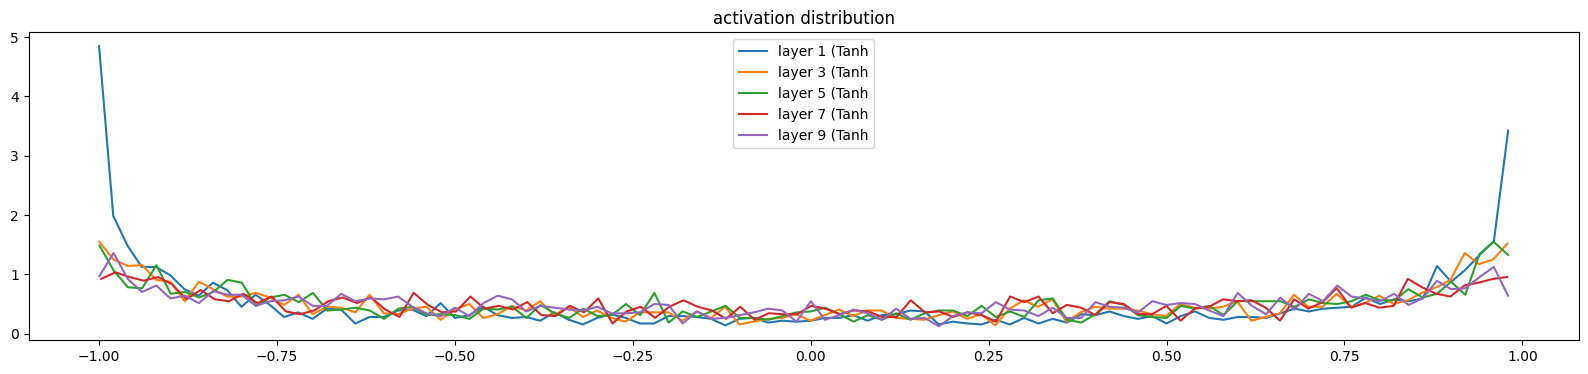

In [64]:
# Visualize histograms

plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]): # Note: Exclude output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')


layer 1 (      Tanh): mean +0.000010, std 3.949997e-04
layer 3 (      Tanh): mean -0.000003, std 3.850313e-04
layer 5 (      Tanh): mean +0.000017, std 3.653753e-04
layer 7 (      Tanh): mean +0.000016, std 3.273966e-04
layer 9 (      Tanh): mean -0.000016, std 3.075680e-04


Text(0.5, 1.0, 'gradient distribution')

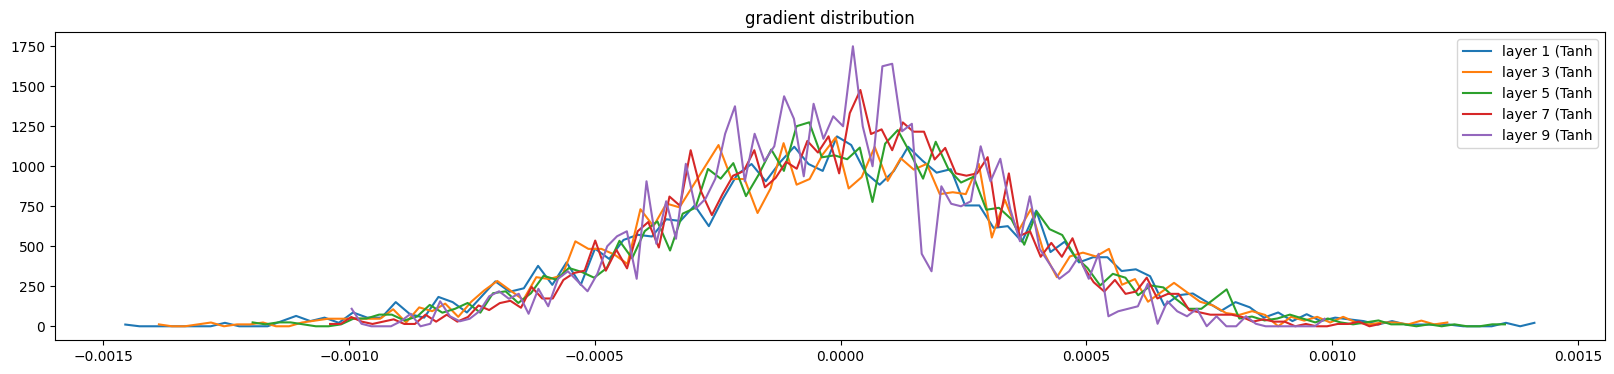

In [65]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')